# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.linear_model import ElasticNet
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import scipy
import seaborn as sns
import matplotlib.pyplot as plt

# Load the datasets from the CSV files

In [2]:
dataset1 = pd.read_csv('/content/Series 5000.csv')

In [3]:
dataset1.head()

,ID,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%),2% proof stress (Mpa),Tensile strength (Mpa),Elongation (%)
0,A 5005 P,1,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,95,125,2
1,A 5005 P,1,4,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,120,145,2
2,A 5005 P,1,6,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,145,165,2
3,A 5005 P,1,8,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,165,185,2
4,A 5005 P,2,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,85,120,4


In [4]:
dataset1.drop("ID", axis=1, inplace=True)
dataset1.columns

Index(['X', 'n', 'Fe (wt%)', 'Mn (wt%)', 'Si (wt%)', 'Al (wt%)', 'Mg (wt%)',
       'Ti (wt%)', 'Cu (wt%)', 'Cr (wt%)', 'Zn (wt%)', '2% proof stress (Mpa)',
       'Tensile strength (Mpa)', 'Elongation (%)'],
      dtype='object')

In [5]:
X = dataset1.drop(['2% proof stress (Mpa)', 'Tensile strength (Mpa)', 'Elongation (%)'], axis=1)
elongation = dataset1['Elongation (%)']  # Change the target variable as needed

In [6]:
X.head()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
0,1,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
1,1,4,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
2,1,6,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
3,1,8,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
4,2,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125


# Split the data into training and testing sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, elongation, test_size=0.2, random_state=42)
print(f"The Shape of X_train : {X_train.shape}")
print(f"The Shape of X_test : {X_test.shape}")
print(f"The Shape of y_train : {y_train.shape}")
print(f"The Shape of y_test : {y_test.shape}")


The Shape of X_train : (92, 11)
The Shape of X_test : (23, 11)
The Shape of y_train : (92,)
The Shape of y_test : (23,)


In [8]:
X.describe()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,1.930435,4.547826,0.233391,0.152696,0.169304,96.461739,2.655217,0.038000,0.060957,0.152000,0.088609
std,0.895620,2.414298,0.060406,0.169671,0.043199,1.242349,1.158007,0.040614,0.026917,0.089904,0.034051
min,1.000000,1.000000,0.130000,0.010000,0.080000,94.250000,0.400000,0.000000,0.020000,0.000000,0.015000
25%,1.000000,2.000000,0.200000,0.050000,0.130000,95.630000,2.050000,0.000000,0.050000,0.050000,0.050000
50%,2.000000,4.000000,0.200000,0.050000,0.200000,96.780000,2.500000,0.030000,0.050000,0.150000,0.100000
75%,3.000000,6.000000,0.250000,0.275000,0.200000,96.900000,3.500000,0.080000,0.080000,0.250000,0.125000
max,4.000000,9.000000,0.350000,0.750000,0.230000,99.190000,5.050000,0.100000,0.100000,0.250000,0.125000


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         115 non-null    int64  
 1   n         115 non-null    int64  
 2   Fe (wt%)  115 non-null    float64
 3   Mn (wt%)  115 non-null    float64
 4   Si (wt%)  115 non-null    float64
 5   Al (wt%)  115 non-null    float64
 6   Mg (wt%)  115 non-null    float64
 7   Ti (wt%)  115 non-null    float64
 8   Cu (wt%)  115 non-null    float64
 9   Cr (wt%)  115 non-null    float64
 10  Zn (wt%)  115 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 10.0 KB


## **Initialize the models**

In [10]:
linear_regression_model = LinearRegression()
ent = ElasticNet()
random_forest_model = RandomForestRegressor()
alpha_value = 1.0  # You can adjust this value based on your needs
ridge_model = Ridge(alpha=alpha_value)
svm_model = SVC(kernel='linear')
gpr_model = GaussianProcessRegressor()


## **Train the models**


In [11]:
ent.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
linear_regression_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
gpr_model.fit(X_train, y_train)

GaussianProcessRegressor()

In [12]:
X_test.head()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
81,2,4,0.23,0.01,0.23,95.65,3.50,0.03,0.03,0.25,0.100
4,2,2,0.35,0.10,0.15,98.33,0.80,0.00,0.10,0.05,0.125
40,3,8,0.20,0.13,0.15,94.25,5.05,0.00,0.05,0.13,0.050
69,2,2,0.25,0.30,0.20,96.90,2.05,0.08,0.08,0.08,0.075
10,1,9,0.18,0.35,0.10,95.58,3.50,0.05,0.08,0.05,0.125


## **Predict the target variable for the test set**

In [13]:
y_pred_linear_regression = linear_regression_model.predict(X_test)
y_pred_elastic_net = ent.predict(X_test)
y_pred_random_forest = random_forest_model.predict(X_test)
y_pred_ridge_model = ridge_model.predict(X_test)
y_pred_svm_model = svm_model.predict(X_test)
y_pred_gpr_model = gpr_model.predict(X_test)

In [14]:
y_pred_linear_regression

array([4.53098632, 4.84724074, 4.33061341, 6.12154269, 2.76854497,
       7.00561889, 4.56856571, 4.90293474, 8.22422684, 6.31661839,
       2.90492735, 9.65828242, 4.19661729, 3.10232786, 3.75928178,
       5.18160978, 5.78717365, 4.96690357, 2.79753706, 5.19508076,
       2.02068843, 4.65530485, 6.42311629])

In [15]:
y_pred_elastic_net

array([5.13605742, 5.53058562, 2.97335768, 6.01328732, 1.82100791,
       5.42532046, 4.68014289, 4.68014289, 6.75846489, 5.15386897,
       3.42031395, 6.97279095, 5.13605742, 3.9405857 , 4.42462949,
       5.53058562, 6.01328732, 4.75345837, 2.373217  , 5.14114643,
       2.08716952, 5.27373012, 6.42434613])

In [16]:
y_pred_random_forest

array([ 4.25,  3.49,  4.  ,  4.25,  2.16,  6.38,  3.44,  3.18,  6.79,
        3.57,  3.96,  9.53,  4.27,  2.79,  3.93,  2.52,  3.82,  3.66,
        3.03,  4.05,  3.7 ,  3.24, 13.44])

In [17]:
y_pred_ridge_model

array([5.23048464, 4.94232173, 3.36071431, 6.33319353, 2.47442688,
       6.59706536, 4.76555531, 5.09422213, 7.83603676, 6.06485562,
       2.54426542, 8.7209626 , 4.90181782, 2.77974218, 3.79433251,
       5.27098855, 6.00452672, 4.86279397, 2.65686994, 5.64433117,
       1.63396083, 4.3473804 , 6.47445666])

In [18]:
y_pred_svm_model

array([ 4,  3,  1,  5,  3,  8,  3,  3,  5,  4,  3, 11,  4,  3,  3,  3,  5,
        4,  3,  4,  2,  3, 12])

In [19]:
y_pred_gpr_model

array([4.14912857, 2.89449342, 1.1786205 , 7.09351735, 1.50062983,
       3.7331636 , 3.26598939, 3.1317416 , 8.19920881, 4.74623433,
       3.69359003, 2.28871493, 3.9199605 , 1.74190111, 2.55567941,
       0.47062929, 2.7627937 , 3.39540507, 3.15958594, 3.68385588,
       3.27069217, 1.19755039, 8.10476373])

## **Calculate the evaluation metrics**

In [20]:
mse_linear_regression = mean_squared_error(y_test, y_pred_linear_regression)
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
mse_random_forest = mean_squared_error(y_test, y_pred_random_forest)
mse_ridge_model = mean_squared_error(y_test, y_pred_ridge_model)
mse_svm_model = mean_squared_error(y_test, y_pred_svm_model)
mse_gpr_model = mean_squared_error(y_test, y_pred_gpr_model)


print(mse_linear_regression)
print(mse_elastic_net)
print(mse_random_forest)
print(mse_ridge_model)
print(mse_svm_model)
print(mse_gpr_model)

2.999119840120397
2.876565145475679
1.7833695652173913
3.0936172218858817
3.1739130434782608
2.6707888940724667


In [21]:
rmse_linear_regression = mean_squared_error(y_test, y_pred_linear_regression, squared=False)
rmse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net, squared=False)
rmse_random_forest = mean_squared_error(y_test, y_pred_random_forest, squared=False)
rmse_ridge_model =  mean_squared_error(y_test, y_pred_ridge_model, squared=False)
rmse_svm_model = mean_squared_error(y_test, y_pred_svm_model, squared=False)
rmse_gpr_model = mean_squared_error(y_test, y_pred_gpr_model, squared=False)


print(rmse_linear_regression)
print(rmse_elastic_net)
print(rmse_random_forest)
print(rmse_ridge_model)
print(rmse_svm_model)
print(rmse_gpr_model)

1.7317967086584953
1.6960439692047133
1.3354286073083022
1.7588681650100675
1.7815479346563372
1.6342548436741642


In [22]:
r2_linear_regression = r2_score(y_test, y_pred_linear_regression)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)
r2_random_forest = r2_score(y_test, y_pred_random_forest)
r2_ridge_model =  r2_score(y_test, y_pred_ridge_model)
r2_svm_model =  r2_score(y_test, y_pred_svm_model)
r2_gpr_model =  r2_score(y_test, y_pred_gpr_model)

print(r2_linear_regression)
print(r2_random_forest)
print(r2_ridge_model)
print(r2_svm_model)
print(r2_gpr_model)

0.047698442122635076
0.43373199279711894
0.017692970961805887
-0.007803121248499245
0.15195238597578942


## **Create a dictionary to store the evaluation metrics**

In [23]:
metrics = {
    'Linear Regression': {'MSE': mse_linear_regression, 'R2 Score': r2_linear_regression},
    'Elastic Net': {'MSE': mse_elastic_net, 'R2 Score': r2_elastic_net},
    'Random Forest': {'MSE': mse_random_forest, 'R2 Score': r2_random_forest},
    'Ridge Regression': {'MSE': mse_ridge_model, 'R2 Score': r2_ridge_model},
    'Support Vector Machine': {'MSE': mse_svm_model, 'R2 Score': r2_svm_model},
    'Gaussian Process Regression': {'MSE': mse_gpr_model, 'R2 Score': r2_gpr_model}
}

## **Plot the evaluation metrics**

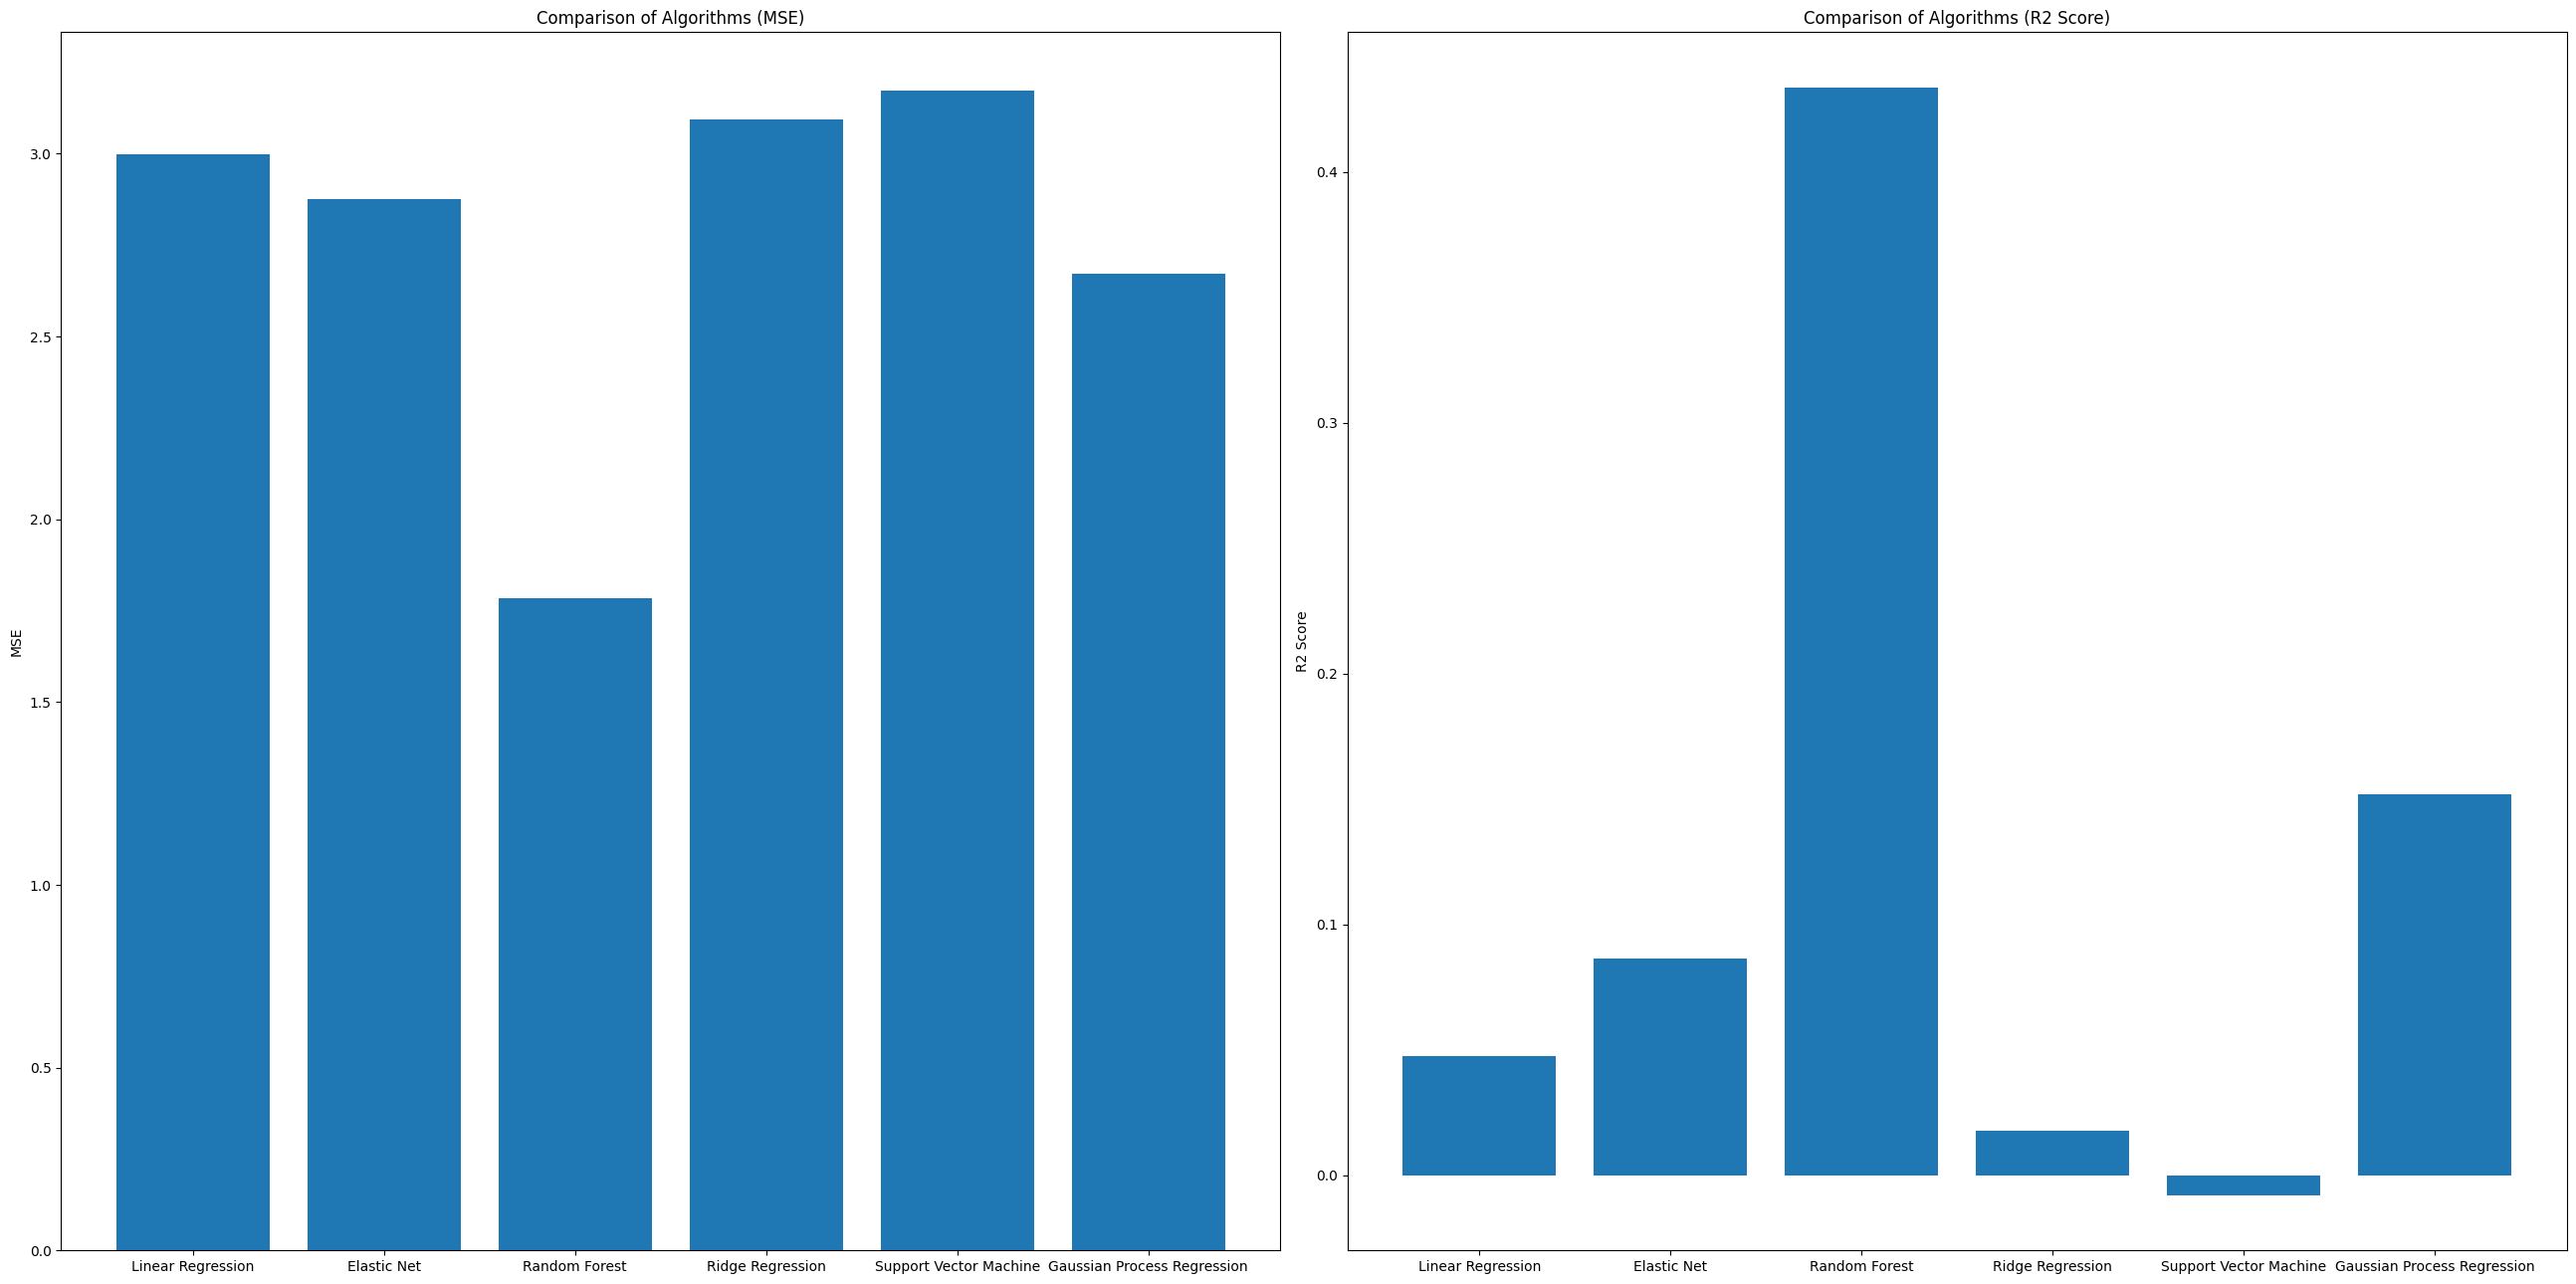

In [24]:
metric_names = ['MSE', 'R2 Score']
num_algorithms = len(metrics)

plt.figure(figsize=(26, 13))

for i, metric in enumerate(metric_names):
    plt.subplot(1, 2, i+1)
    metric_values = [metrics[algorithm][metric] for algorithm in metrics]
    plt.bar(range(num_algorithms), metric_values)
    plt.xticks(range(num_algorithms), metrics.keys())
    plt.ylabel(metric)
    plt.title(f'Comparison of Algorithms ({metric})')

plt.tight_layout()
plt.show()

In [25]:
print('Linear Regression')
print('MSE:', metrics['Linear Regression']['MSE'])
print('R2 Score:', metrics['Linear Regression']['R2 Score'])
print()

Linear Regression
MSE: 2.999119840120397
R2 Score: 0.047698442122635076



In [26]:
print('Ridge Regression')
print('MSE:', metrics['Ridge Regression']['MSE'])
print('R2 Score:', metrics['Ridge Regression']['R2 Score'])

Ridge Regression
MSE: 3.0936172218858817
R2 Score: 0.017692970961805887


In [27]:
print('Elastic Net')
print('MSE:', metrics['Elastic Net']['MSE'])
print('R2 Score:', metrics['Elastic Net']['R2 Score'])
print()

Elastic Net
MSE: 2.876565145475679
R2 Score: 0.08661286797320888



In [28]:
print('Support Vector Machine')
print('MSE:', metrics['Support Vector Machine']['MSE'])
print('R2 Score:', metrics['Support Vector Machine']['R2 Score'])

Support Vector Machine
MSE: 3.1739130434782608
R2 Score: -0.007803121248499245


In [29]:
print('Random Forest')
print('MSE:', metrics['Random Forest']['MSE'])
print('R2 Score:', metrics['Random Forest']['R2 Score'])

Random Forest
MSE: 1.7833695652173913
R2 Score: 0.43373199279711894


In [30]:
print('Gaussian Process Regression')
print('MSE:', metrics['Gaussian Process Regression']['MSE'])
print('R2 Score:', metrics['Gaussian Process Regression']['R2 Score'])

Gaussian Process Regression
MSE: 2.6707888940724667
R2 Score: 0.15195238597578942






## **Graph Plotting**



In [31]:
elongation = dataset1['Elongation (%)']

x = dataset1['X']
n = dataset1['n']
Fe = dataset1['Fe (wt%)']
Mn = dataset1['Mn (wt%)']
Si = dataset1['Si (wt%)']
Al = dataset1['Al (wt%)']
Mg = dataset1['Mg (wt%)']
Ti = dataset1['Ti (wt%)']
Cu = dataset1['Cu (wt%)']
Cr = dataset1['Cr (wt%)']
Zn = dataset1['Zn (wt%)']

In [32]:
dataset= pd.read_csv('/content/Series 5000.csv')

id= dataset['ID']

In [33]:
sns.set_style("ticks")

In [34]:
from google.colab import files

In [35]:
x = dataset1['X']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.12713659699533386


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

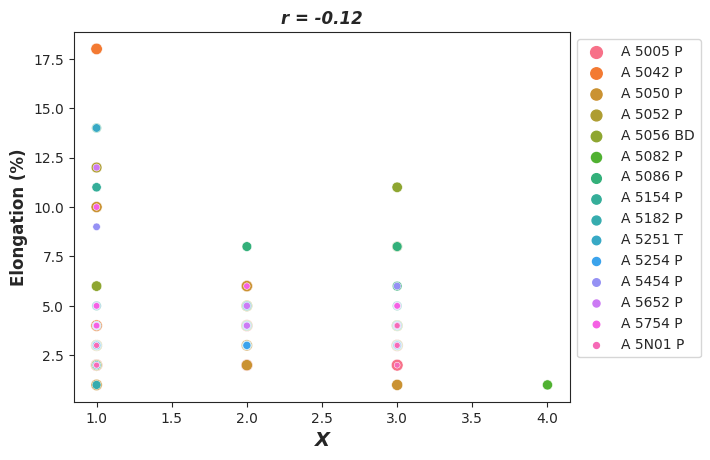

In [39]:
sns.scatterplot(x=dataset1['X'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('X', fontdict={'size': 14, 'weight': 'bold', 'style': 'italic'})
plt.ylabel('Elongation (%)', fontdict={'size': 12 , 'weight': 'bold'})
plt.title('r = -0.12', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('X vs Elongation (%).pdf')
files.download('X vs Elongation (%).pdf')
plt.show

In [40]:
x = dataset1['n']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.6040515353528503


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

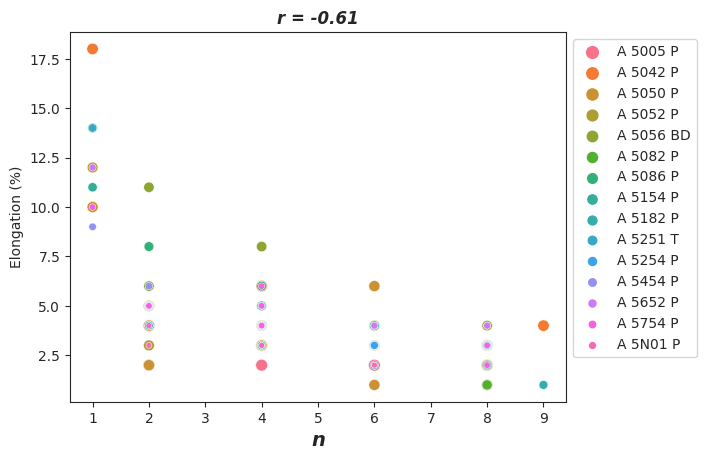

In [41]:
sns.scatterplot(x=dataset1['n'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('n', fontdict={'size': 14, 'weight': 'bold', 'style': 'italic'})
plt.title('r = -0.61', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('n vs Elongation (%).pdf')
files.download('n vs Elongation (%).pdf')
plt.show

In [42]:
x = dataset1['Fe (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.16682810650046723


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

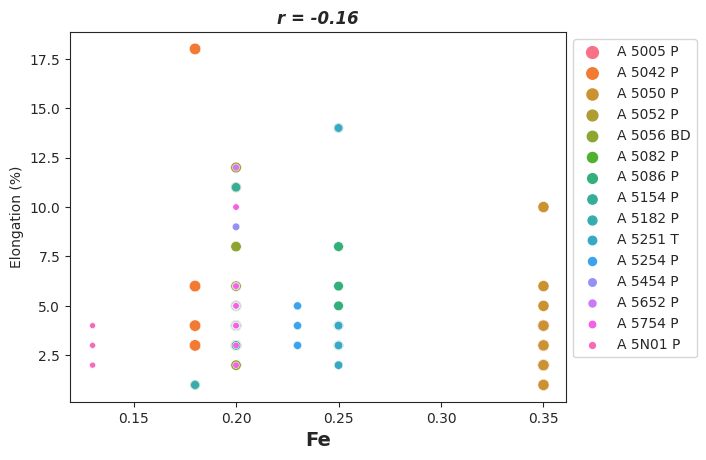

In [43]:
sns.scatterplot(x=dataset1['Fe (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Fe', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.16', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Fe vs Elongation (%).pdf')
files.download('Fe vs Elongation (%).pdf')
plt.show

In [44]:
x = dataset1['Mn (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.2382038351355508


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

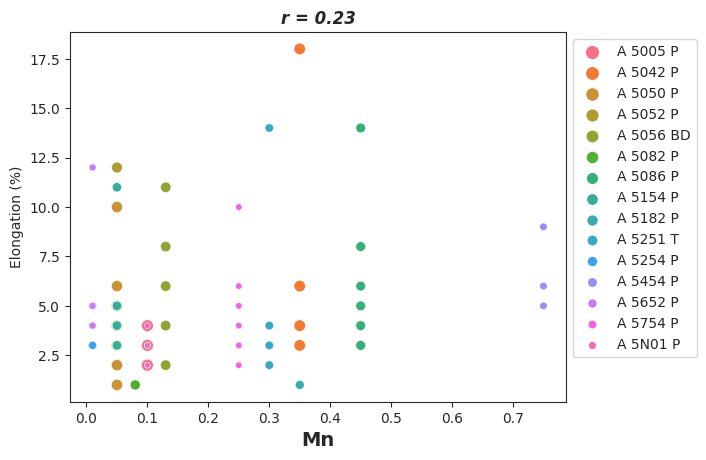

In [45]:
sns.scatterplot(x=dataset1['Mn (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Mn', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.23', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Mn vs Elongation (%).pdf')
files.download('Mn vs Elongation (%).pdf')
plt.show

In [46]:
x = dataset1['Si (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.01502822077983016


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

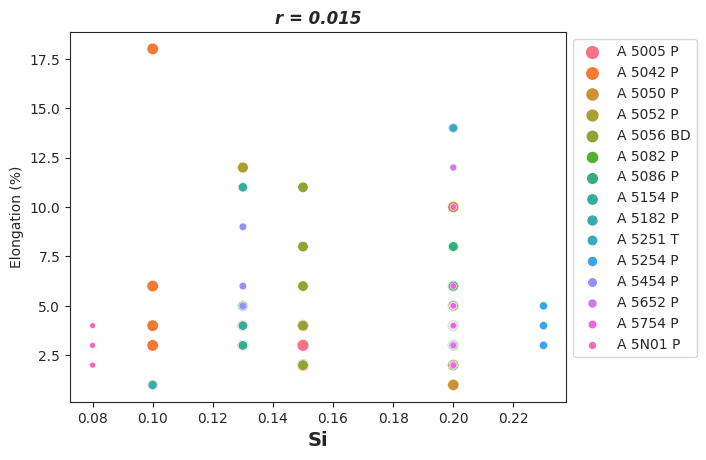

In [48]:
sns.scatterplot(x=dataset1['Si (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Si', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.015', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Si vs Elongation (%).pdf')
files.download('Si vs Elongation (%).pdf')
plt.show

In [49]:
x = dataset1['Al (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.29676946263228793


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

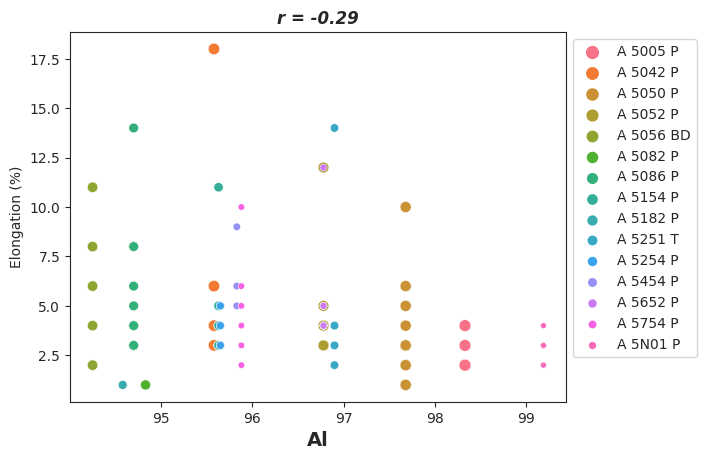

In [50]:
sns.scatterplot(x=dataset1['Al (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Al', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.29', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Al vs Elongation (%).pdf')
files.download('Al vs Elongation (%).pdf')
plt.show

In [51]:
x = dataset1['Mg (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.28128721257658745


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

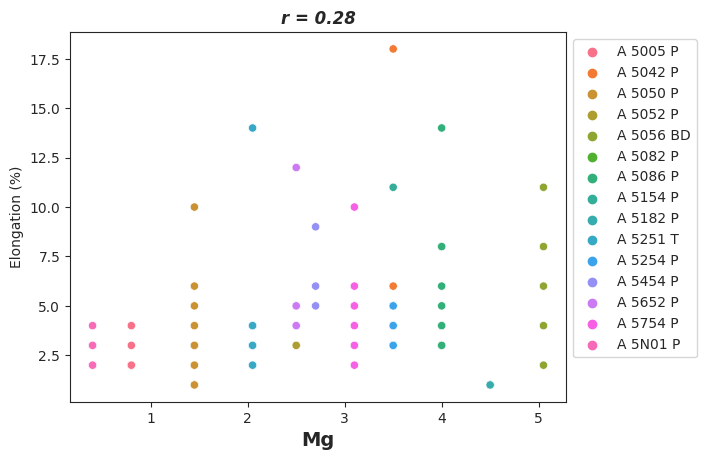

In [52]:
sns.scatterplot(x=dataset1['Mg (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Mg', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.28', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Mg vs Elongation (%).pdf')
files.download('Mg vs Elongation (%).pdf')
plt.show

In [53]:
x = dataset1['Ti (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.15923577506583958


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

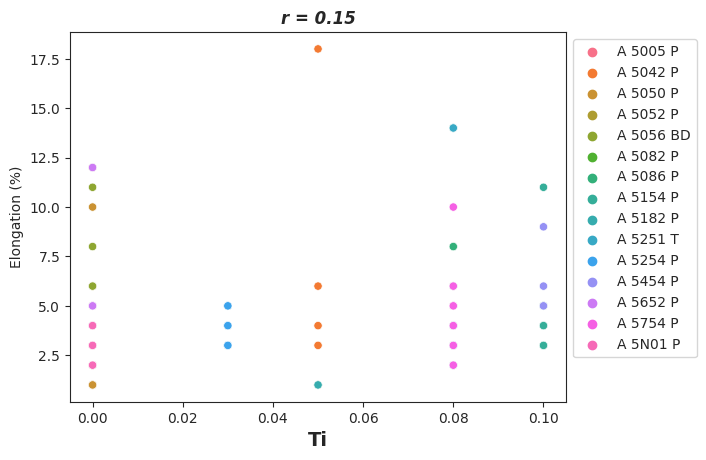

In [54]:
sns.scatterplot(x=dataset1['Ti (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Ti', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.15', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Ti vs Elongation (%).pdf')
files.download('Ti vs Elongation (%).pdf')
plt.show

In [55]:
x = dataset1['Cu (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation= dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.21210228609857235


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

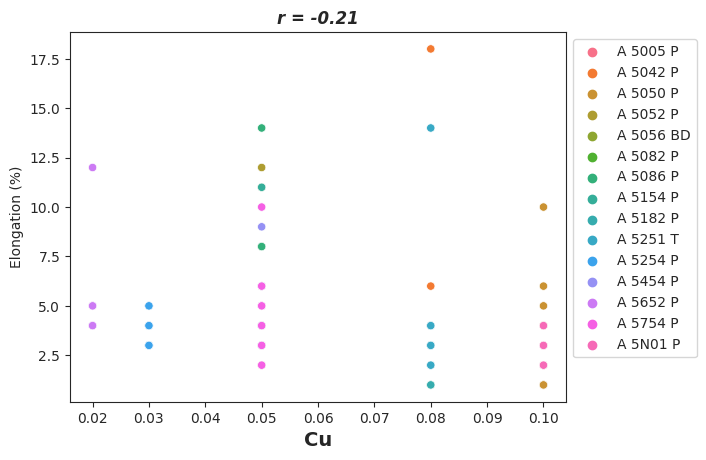

In [56]:
sns.scatterplot(x=dataset1['Cu (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Cu', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.21', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Cu vs Elongation (%).pdf')
files.download('Cu vs Elongation (%).pdf')
plt.show

In [57]:
x = dataset1['Cr (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]

print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.11287209330499148


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

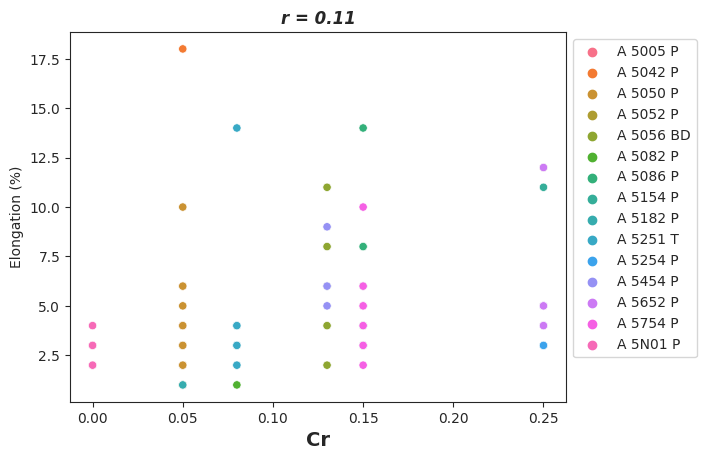

In [58]:
sns.scatterplot(x=dataset1['Cr (wt%)'], y=dataset1['Elongation (%)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Cr', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.11', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Cr vs Elongation (%).pdf')
files.download('Cr vs Elongation (%).pdf')
plt.show

In [59]:
x = dataset1['Zn (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
elongation = dataset1['Elongation (%)']
value_to_append = elongation.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]

print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.022289504852468573


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

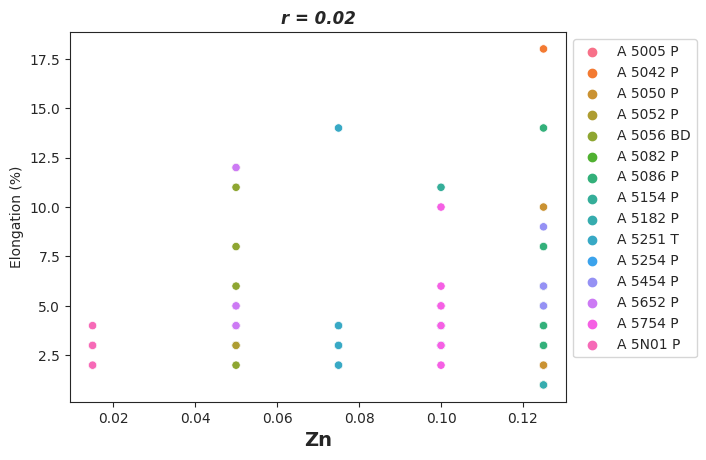

In [60]:
sns.scatterplot(x=dataset1['Zn (wt%)'], y=dataset['Elongation (%)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Zn', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.02', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Zn vs Elongation (%).pdf')
files.download('Zn vs Elongation (%).pdf')
plt.show

## **Proof Stress Vs Different ML Modles**

In [ ]:
sns.set_style("ticks")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

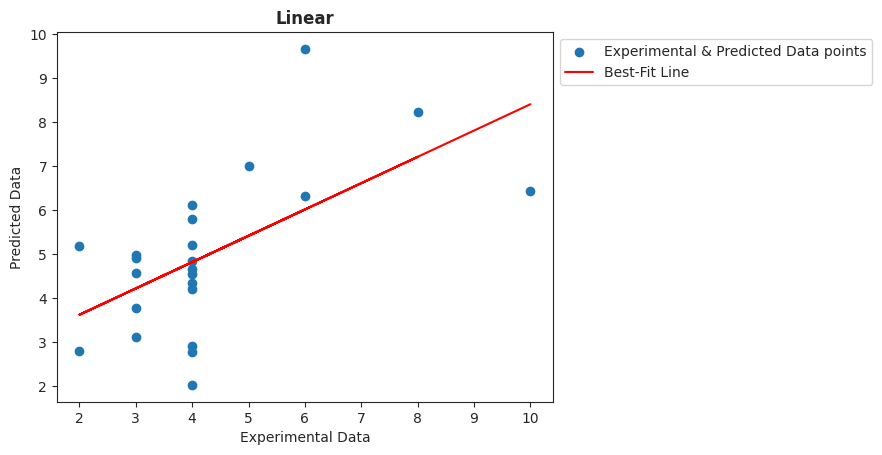

In [63]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)

x = np.array([4, 4, 4, 4, 4, 5, 3, 3, 8, 6, 4, 6, 4, 3, 3, 2, 4, 3, 2, 4, 4, 4, 10])
y_pred_values = np.array([4.53098632, 4.84724074, 4.33061341, 6.12154269, 2.76854497,
       7.00561889, 4.56856571, 4.90293474, 8.22422684, 6.31661839,
       2.90492735, 9.65828242, 4.19661729, 3.10232786, 3.75928178,
       5.18160978, 5.78717365, 4.96690357, 2.79753706, 5.19508076,
       2.02068843, 4.65530485, 6.42311629])

data = {'x1': x, 'y_pred_linear_regression': y_pred_values}
df = pd.DataFrame(data)
# plt.figure(figsize=(8, 8))
plt.scatter(x='x1', y='y_pred_linear_regression', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Linear',  fontdict={'weight': 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Linear Regression Model.pdf')
files.download('Linear Regression Model.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

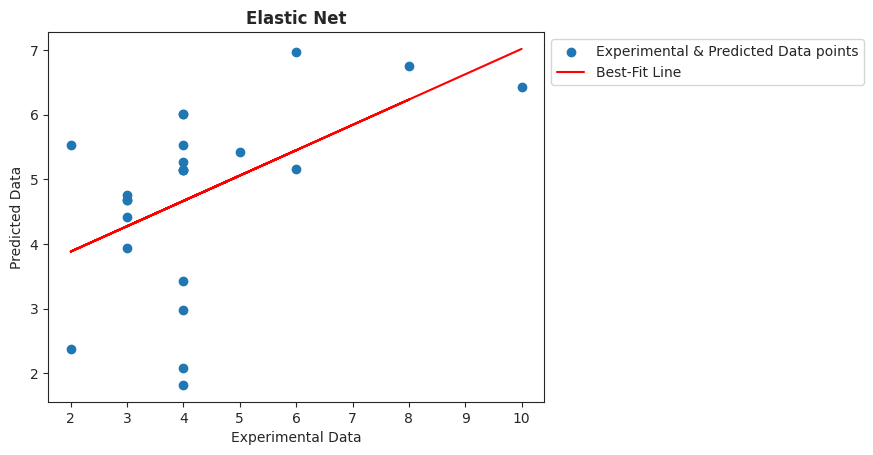

In [72]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1_values = np.array([4, 4, 4, 4, 4, 5, 3, 3, 8, 6, 4, 6, 4, 3, 3, 2, 4, 3, 2, 4, 4, 4, 10])
y_pred_values = np.array([5.13605742, 5.53058562, 2.97335768, 6.01328732, 1.82100791,
                          5.42532046, 4.68014289, 4.68014289, 6.75846489, 5.15386897,
                          3.42031395, 6.97279095, 5.13605742, 3.9405857, 4.42462949,
                          5.53058562, 6.01328732, 4.75345837, 2.373217, 5.14114643,
                          2.08716952, 5.27373012, 6.42434613])

# Create a DataFrame
data = {'x1': x1_values, 'y_pred_elastic_net': y_pred_values}
df = pd.DataFrame(data)

# Create the scatter plot
plt.scatter(x='x1', y='y_pred_elastic_net', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x1_values, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x1_values, fit_line(x1_values), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Elastic Net', fontdict={'weight': 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Elastic Net.pdf')
files.download('Elastic Net.pdf')
plt.show()


In [ ]:
sns.set_style("ticks")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

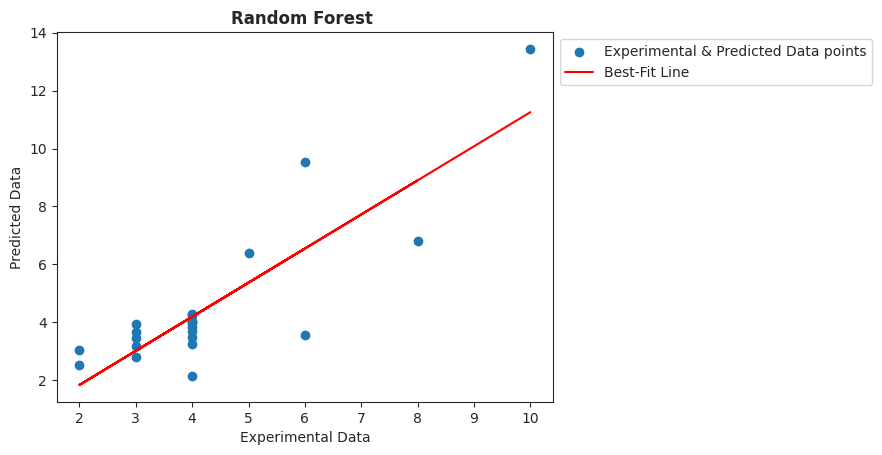

In [73]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1_values = np.array([4, 4, 4, 4, 4, 5, 3, 3, 8, 6, 4, 6, 4, 3, 3, 2, 4, 3, 2, 4, 4, 4, 10])
y_pred_values = np.array([ 4.25,  3.49,  4.  ,  4.25,  2.16,  6.38,  3.44,  3.18,  6.79,
        3.57,  3.96,  9.53,  4.27,  2.79,  3.93,  2.52,  3.82,  3.66,
        3.03,  4.05,  3.7 ,  3.24, 13.44])
data = {'x1': x, 'y_pred_random_forest': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_random_forest', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Random Forest ', fontdict= {'weight' : 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Random Forest.pdf')
files.download('Random Forest.pdf')
plt.show()

In [ ]:
sns.set_style("ticks")

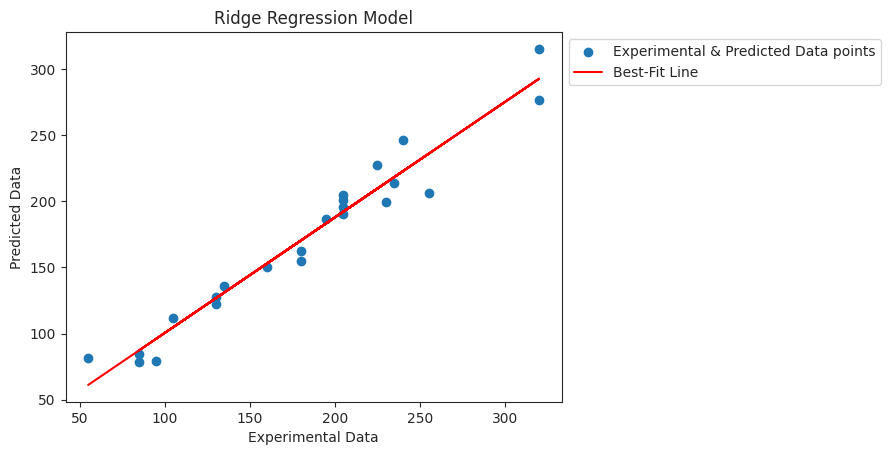

In [ ]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
y_pred_values = np.array([195.67401565,  84.51614887, 315.17119277, 122.40309891,
       276.6639441 , 214.06750238, 155.22843174, 150.19476056,
       186.27584073, 199.6342832 , 204.47065751, 206.62785191,
       200.70768683, 111.62985149, 136.10771839,  79.48247769,
       127.43677009, 162.25697279, 246.34040876, 190.64857404,
       227.22864797,  78.80451866,  81.83604796])
data = {'x1': x, 'y_pred_ridge_model': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_ridge_model', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Ridge' , fontdict= {'weight' : 'bold'})
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


## **End**

In [ ]:
sns.set_style("ticks")

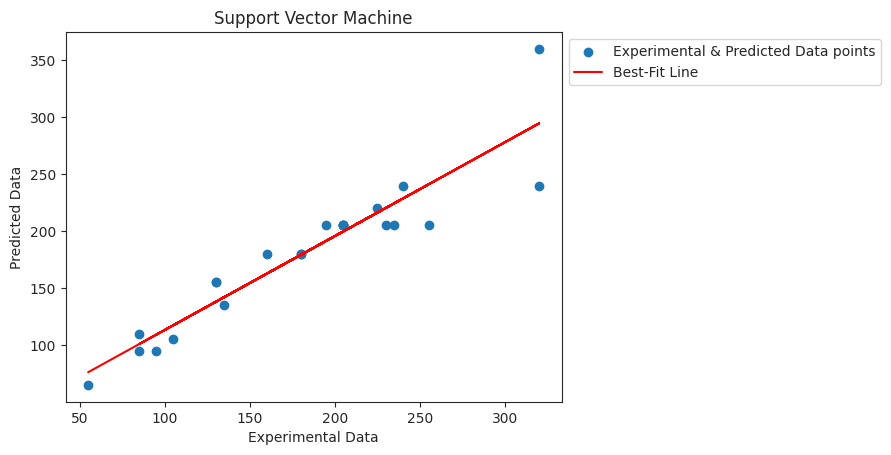

In [ ]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
y_pred_values = np.array([205, 110, 360, 155, 240, 205, 180, 180, 205, 205, 205, 205, 205,
       105, 135,  95, 155, 180, 240, 205, 220,  95,  65])
data = {'x1': x, 'y_pred_svm_model': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_svm_model', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Support Vector Machine')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


In [ ]:
sns.set_style("ticks")

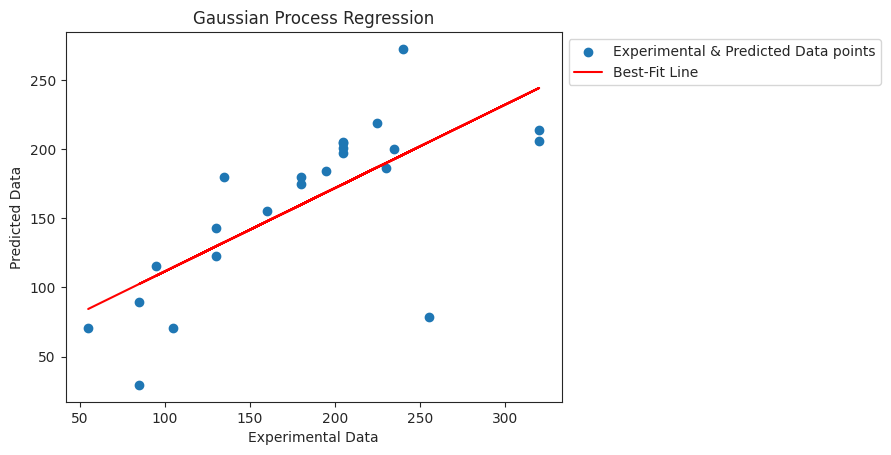

In [ ]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
y_pred_values = np.array([200.86602002,  89.3281031 , 206.04469284, 122.64863754,
       213.47589737, 199.87934866, 179.46174088, 155.56203656,
       184.03026429, 186.16426469, 204.77248501,  78.64697436,
       197.01966535,  70.8840836 , 180.07326549, 115.57551697,
       142.98184776, 174.80934528, 272.32232281, 204.51153664,
       218.49777835,  29.5337507 ,  70.77291736])
data = {'x1': x, 'y_pred_gpr_model': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_gpr_model', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Gaussian Process Regression')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()
